# Supervised Learning - Random Forest untuk Rekomendasi Tanaman

Notebook detail ini menjelaskan proses supervised learning menggunakan **Random Forest Classifier** untuk memprediksi jenis tanaman berdasarkan fitur tanah dan lingkungan. Setiap code cell dilengkapi penjelasan teknis, alasan penggunaan, dan interpretasi hasil agar mudah dipahami oleh anggota kelompok.

Peran notebook ini dalam project:

- Input: `N`, `P`, `K`, `temperature`, `humidity`, `ph`, dan `rainfall`.
- Output: `label` atau jenis tanaman yang direkomendasikan.
- Tujuan: membangun dan mengevaluasi model rekomendasi tanaman untuk konteks Smart Farming.


## 1. Import Library

**Tujuan cell:** memanggil seluruh library yang dibutuhkan untuk membaca data, visualisasi, training model, evaluasi, dan penyimpanan model.

**Penjelasan teknis:**

- `pandas` digunakan untuk membaca dan mengolah dataset berbentuk tabel.
- `numpy` digunakan untuk operasi numerik, terutama saat mengurutkan probabilitas rekomendasi tanaman.
- `matplotlib` dan `seaborn` digunakan untuk membuat grafik.
- `RandomForestClassifier` adalah algoritma supervised learning yang digunakan untuk klasifikasi jenis tanaman.
- `train_test_split` digunakan untuk membagi data menjadi data latih dan data uji.
- `StratifiedKFold` dan `cross_val_score` digunakan untuk validasi silang.
- `accuracy_score`, `classification_report`, dan `confusion_matrix` digunakan untuk evaluasi model.
- `joblib` digunakan untuk menyimpan model yang sudah dilatih.

**Alasan:** semua library ini adalah komponen standar untuk workflow machine learning sederhana di Python dan tersedia di Kaggle Notebook.


In [14]:
import os
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
DATA_PATH = "/kaggle/input/datasets/atharvaingle/crop-recommendation-dataset/Crop_recommendation.csv"


### Interpretasi hasil cell 1

Cell ini tidak menghasilkan output karena hanya memuat library dan konfigurasi awal. Jika cell ini berjalan tanpa error, berarti semua library yang dibutuhkan tersedia di environment Kaggle. Variabel `RANDOM_STATE` dan `DATA_PATH` juga sudah siap digunakan oleh cell berikutnya.


## 2. Memuat Dataset

**Tujuan cell:** membaca file dataset dari direktori Kaggle dan menampilkan ukuran serta beberapa baris awal data.

**Penjelasan teknis:**

- `os.path.exists(DATA_PATH)` mengecek apakah file dataset benar-benar tersedia pada path Kaggle.
- Jika file tidak ditemukan, program menghentikan proses dengan `FileNotFoundError` agar error-nya jelas.
- `pd.read_csv(DATA_PATH)` membaca file CSV menjadi DataFrame bernama `df`.
- `df.shape` menampilkan jumlah baris dan kolom.
- `df.head()` menampilkan lima data pertama.

**Alasan:** sebelum melakukan analisis, kita harus memastikan dataset berhasil dibaca dan format kolomnya sesuai dengan kebutuhan model.


In [15]:
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Dataset tidak ditemukan: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)

print("Ukuran dataset:", df.shape)
df.head()


Ukuran dataset: (2200, 8)


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


### Interpretasi hasil cell 2

Output menunjukkan dataset berhasil dibaca dengan ukuran **2200 baris dan 8 kolom**. Lima baris pertama memperlihatkan bahwa dataset berisi fitur `N`, `P`, `K`, `temperature`, `humidity`, `ph`, `rainfall`, dan `label`. Ini berarti struktur dataset sudah sesuai dengan kebutuhan project.


## 3. Cek Struktur dan Kualitas Data

**Tujuan cell:** mengecek struktur kolom, missing value, duplikasi, dan ringkasan statistik fitur numerik.

**Penjelasan teknis:**

- `df.columns.tolist()` menampilkan daftar nama kolom.
- `df.isna().sum()` menghitung jumlah nilai kosong pada setiap kolom.
- `df.duplicated().sum()` menghitung jumlah baris duplikat.
- `df.describe().T` menampilkan statistik seperti mean, standar deviasi, nilai minimum, median, dan maksimum.

**Alasan:** kualitas data harus dicek sebelum model dilatih. Missing value atau duplikasi dapat memengaruhi hasil training dan evaluasi model.


In [16]:
print("Kolom dataset:")
print(df.columns.tolist())

print("\nMissing value:")
print(df.isna().sum())

print("\nJumlah duplikasi:", df.duplicated().sum())

print("\nRingkasan statistik:")
df.describe().T


Kolom dataset:
['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']

Missing value:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

Jumlah duplikasi: 0

Ringkasan statistik:


,count,mean,std,min,25%,50%,75%,max
N,2200.0,50.551818,36.917334,0.000000,21.000000,37.000000,84.250000,140.000000
P,2200.0,53.362727,32.985883,5.000000,28.000000,51.000000,68.000000,145.000000
K,2200.0,48.149091,50.647931,5.000000,20.000000,32.000000,49.000000,205.000000
temperature,2200.0,25.616244,5.063749,8.825675,22.769375,25.598693,28.561654,43.675493
humidity,2200.0,71.481779,22.263812,14.258040,60.261953,80.473146,89.948771,99.981876
ph,2200.0,6.469480,0.773938,3.504752,5.971693,6.425045,6.923643,9.935091
rainfall,2200.0,103.463655,54.958389,20.211267,64.551686,94.867624,124.267508,298.560117


### Interpretasi hasil cell 3

Output menunjukkan seluruh kolom yang dibutuhkan tersedia. Missing value bernilai 0 pada semua kolom, sehingga tidak diperlukan imputasi data. Jumlah duplikasi juga 0, sehingga tidak ada baris yang perlu dihapus. Ringkasan statistik menunjukkan rentang setiap fitur cukup berbeda, tetapi untuk Random Forest scaling tidak wajib karena algoritma ini berbasis decision tree.


## 4. Menentukan Fitur dan Target

**Tujuan cell:** memisahkan kolom fitur input dan kolom target.

**Penjelasan teknis:**

- `feature_columns` berisi daftar fitur tanah dan lingkungan yang digunakan untuk prediksi.
- `target_column` adalah `label`, yaitu jenis tanaman.
- `X` berisi fitur input model.
- `y` berisi target yang ingin diprediksi.

**Alasan:** supervised learning membutuhkan pasangan input dan output. Dalam project ini, inputnya adalah kondisi lahan, sedangkan outputnya adalah jenis tanaman.


In [17]:
feature_columns = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]
target_column = "label"

X = df[feature_columns]
y = df[target_column]

print("Jumlah fitur:", X.shape[1])
print("Jumlah jenis tanaman:", y.nunique())


Jumlah fitur: 7
Jumlah jenis tanaman: 22


### Interpretasi hasil cell 4

Output menunjukkan model menggunakan **7 fitur input** dan memiliki **22 kelas tanaman**. Artinya, masalah yang diselesaikan adalah klasifikasi multikelas, karena model harus memilih satu dari 22 jenis tanaman.


## 5. Melihat Distribusi Jenis Tanaman

**Tujuan cell:** menampilkan jumlah data untuk setiap jenis tanaman dalam bentuk grafik.

**Penjelasan teknis:**

- `sns.countplot()` menghitung dan memvisualisasikan jumlah data pada setiap kelas tanaman.
- Sumbu Y berisi nama tanaman.
- Sumbu X berisi jumlah data.
- `order=df[target_column].value_counts().index` mengurutkan label berdasarkan jumlah data.

**Alasan:** distribusi kelas penting untuk supervised learning. Jika data sangat tidak seimbang, model bisa bias ke kelas yang jumlah datanya lebih banyak.


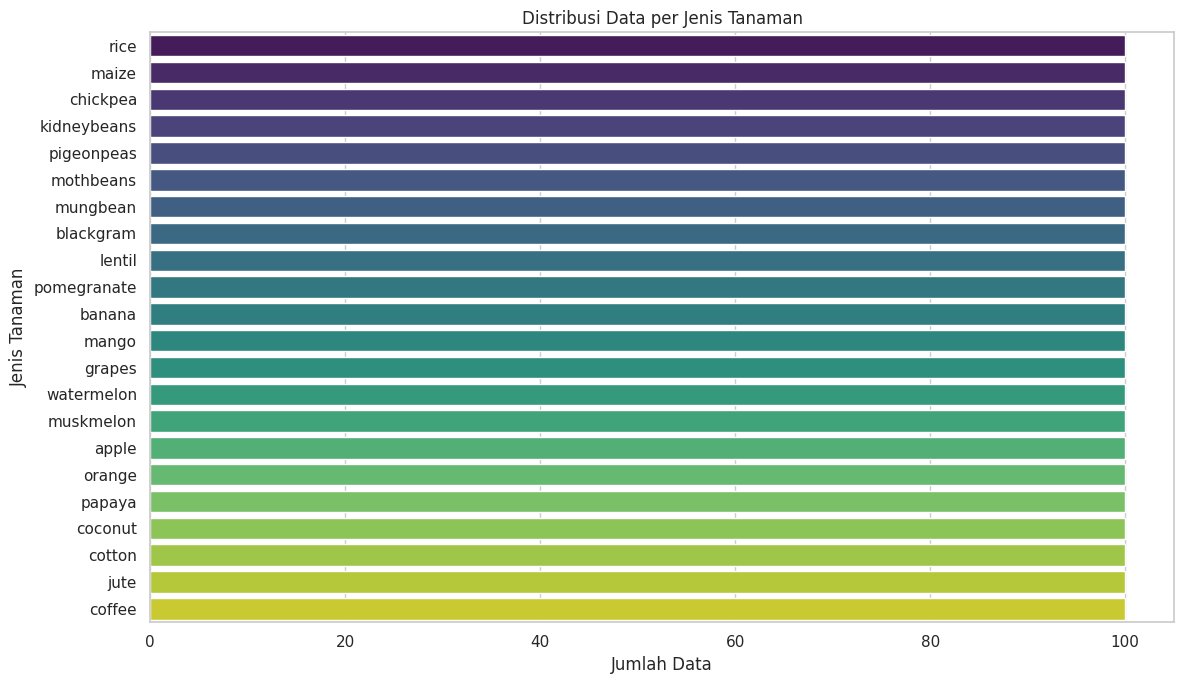

In [18]:
plt.figure(figsize=(12, 7))
sns.countplot(data=df, y=target_column, order=df[target_column].value_counts().index, palette="viridis")
plt.title("Distribusi Data per Jenis Tanaman")
plt.xlabel("Jumlah Data")
plt.ylabel("Jenis Tanaman")
plt.tight_layout()
plt.show()


### Interpretasi hasil cell 5

Grafik menunjukkan setiap jenis tanaman memiliki jumlah data yang sama, yaitu 100 data. Ini berarti dataset seimbang. Kondisi ini baik untuk training Random Forest karena model tidak terdorong untuk lebih memihak kelas tertentu.


## 6. Membagi Data Latih dan Data Uji

**Tujuan cell:** membagi dataset menjadi data latih dan data uji.

**Penjelasan teknis:**

- `test_size=0.2` berarti 20% data digunakan sebagai data uji dan 80% sebagai data latih.
- `random_state=42` membuat pembagian data konsisten setiap kali notebook dijalankan.
- `stratify=y` menjaga proporsi setiap jenis tanaman tetap seimbang pada data latih dan data uji.

**Alasan:** model perlu diuji pada data yang tidak digunakan saat training agar kita tahu apakah model bisa melakukan generalisasi.


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Data latih:", X_train.shape)
print("Data uji:", X_test.shape)


Data latih: (1760, 7)
Data uji: (440, 7)


### Interpretasi hasil cell 6

Output menunjukkan data dibagi menjadi **1760 data latih** dan **440 data uji**. Karena split dilakukan dengan stratifikasi, setiap tanaman tetap memiliki proporsi yang seimbang pada data latih dan data uji.


## 7. Melatih Model Random Forest

**Tujuan cell:** membuat dan melatih model Random Forest.

**Penjelasan teknis:**

- `RandomForestClassifier` membuat model klasifikasi berbasis banyak decision tree.
- `n_estimators=200` berarti model menggunakan 200 pohon keputusan.
- `random_state=42` menjaga hasil tetap konsisten.
- `n_jobs=-1` membuat training memakai seluruh core CPU yang tersedia.
- `fit(X_train, y_train)` melatih model menggunakan data latih.

**Alasan:** Random Forest dipilih karena cocok untuk data tabular, mampu menangani klasifikasi banyak kelas, dan menyediakan feature importance.


In [20]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

rf_model.fit(X_train, y_train)
print("Model selesai dilatih.")


Model selesai dilatih.


### Interpretasi hasil cell 7

Output `Model selesai dilatih` berarti Random Forest berhasil belajar dari data latih. Pada tahap ini model sudah memiliki pola hubungan antara fitur tanah/lingkungan dan label tanaman.


## 8. Evaluasi Model dan Cek Overfitting

**Tujuan cell:** mengevaluasi performa model pada data latih dan data uji, lalu mengecek indikasi overfitting atau underfitting.

**Penjelasan teknis:**

- `predict(X_train)` memprediksi data latih.
- `predict(X_test)` memprediksi data uji.
- `accuracy_score()` menghitung akurasi.
- `gap = train_accuracy - test_accuracy` digunakan untuk melihat selisih performa antara data latih dan uji.
- `classification_report()` menampilkan precision, recall, dan F1-score untuk setiap tanaman.

**Alasan:** akurasi saja tidak cukup. Classification report membantu melihat performa model pada setiap jenis tanaman, sedangkan gap train-test membantu membaca potensi overfitting.


In [21]:
train_pred = rf_model.predict(X_train)
test_pred = rf_model.predict(X_test)

train_accuracy = accuracy_score(y_train, train_pred)
test_accuracy = accuracy_score(y_test, test_pred)
gap = train_accuracy - test_accuracy

print(f"Train Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")
print(f"Gap Train-Test: {gap:.4f}")

if gap > 0.05:
    print("Catatan: ada indikasi overfitting karena gap cukup besar.")
elif train_accuracy < 0.85 and test_accuracy < 0.85:
    print("Catatan: ada indikasi underfitting karena performa masih rendah.")
else:
    print("Catatan: tidak terlihat indikasi overfitting atau underfitting yang besar.")

print("\nClassification Report:")
print(classification_report(y_test, test_pred))


Train Accuracy: 1.0000
Test Accuracy : 0.9955
Gap Train-Test: 0.0045
Catatan: tidak terlihat indikasi overfitting atau underfitting yang besar.

Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.

### Interpretasi hasil cell 8

Model memperoleh **Train Accuracy 1.0000** dan **Test Accuracy 0.9955**. Gap antara train dan test hanya **0.0045**, sehingga tidak terlihat overfitting yang besar. Classification report juga menunjukkan sebagian besar kelas memiliki precision, recall, dan F1-score mendekati 1.00. Dengan kata lain, model sangat baik dalam membedakan jenis tanaman pada dataset ini.


## 9. Confusion Matrix

**Tujuan cell:** menampilkan confusion matrix untuk melihat detail benar-salah prediksi model.

**Penjelasan teknis:**

- `confusion_matrix(y_test, test_pred, labels=labels)` membuat matriks perbandingan antara label aktual dan prediksi.
- Baris menunjukkan label aktual.
- Kolom menunjukkan label prediksi.
- Angka pada diagonal utama menunjukkan prediksi yang benar.
- Angka di luar diagonal menunjukkan kesalahan prediksi.

**Alasan:** confusion matrix memudahkan kita melihat kelas tanaman mana yang masih tertukar oleh model.


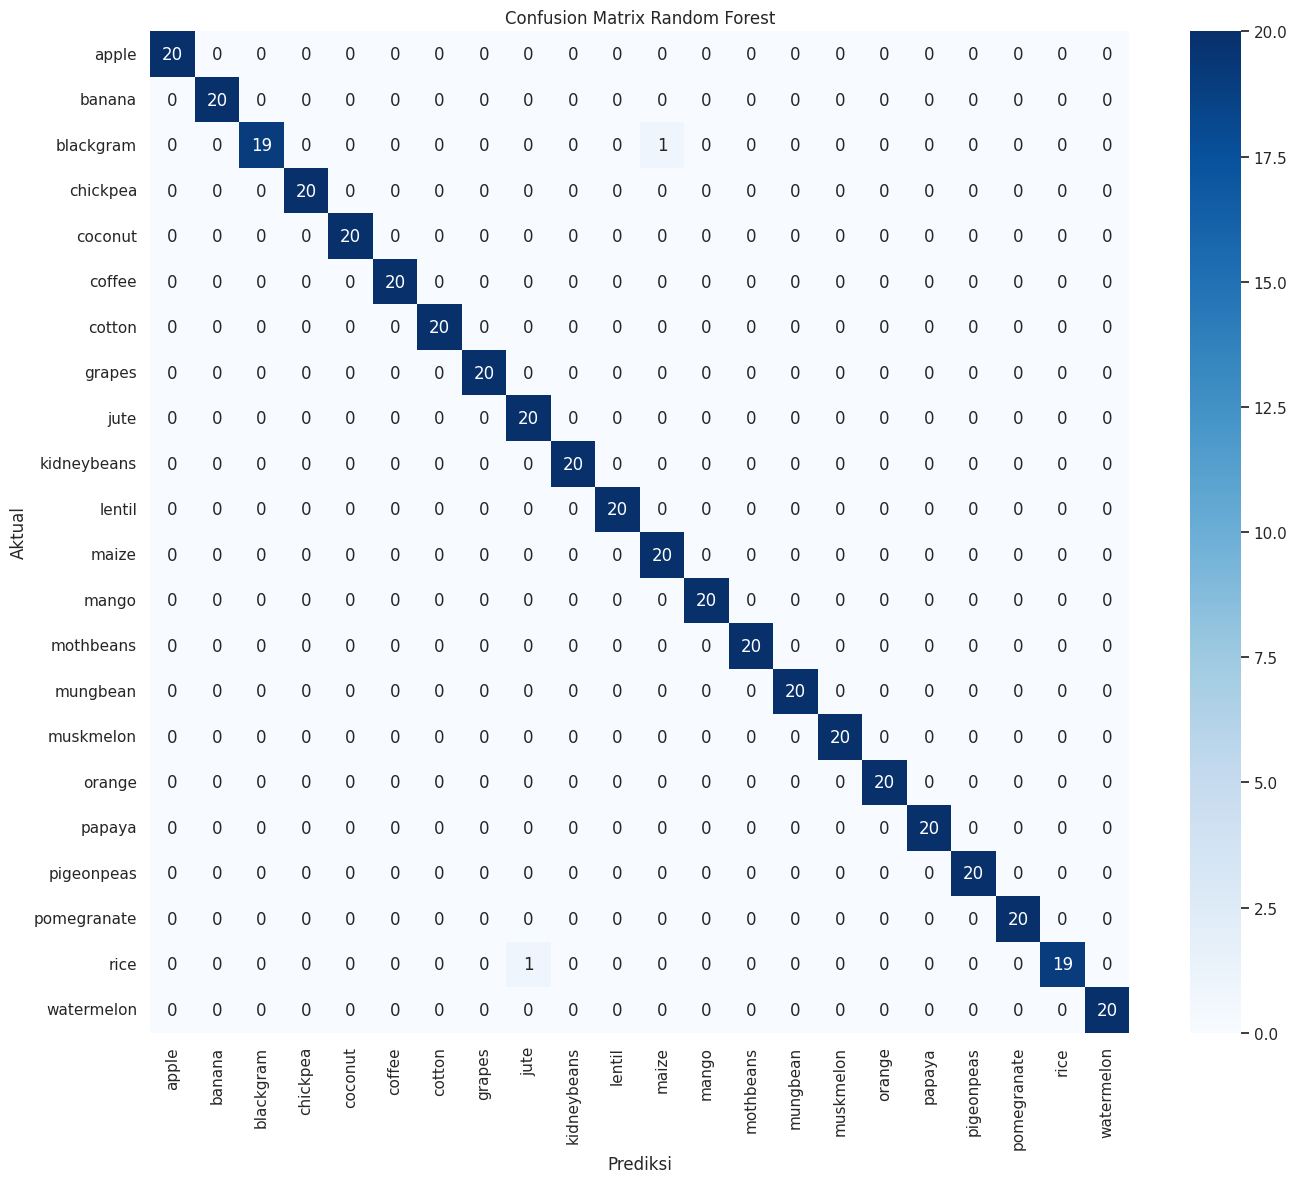

In [22]:
labels = sorted(y.unique())
cm = confusion_matrix(y_test, test_pred, labels=labels)

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix Random Forest")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


### Interpretasi hasil cell 9

Confusion matrix menunjukkan mayoritas prediksi berada pada diagonal utama, yang berarti prediksi model sama dengan label aktual. Jika ada angka di luar diagonal, itu menunjukkan kelas tanaman yang tertukar. Karena angka di luar diagonal sangat sedikit, performa model dapat dianggap sangat baik.


## 10. Cross-Validation

**Tujuan cell:** mengecek stabilitas performa model dengan validasi silang 5-fold.

**Penjelasan teknis:**

- `StratifiedKFold(n_splits=5)` membagi data menjadi 5 bagian dengan proporsi kelas tetap seimbang.
- `cross_val_score()` melatih dan menguji model sebanyak 5 kali pada pembagian data yang berbeda.
- Output yang dilihat adalah accuracy setiap fold, rata-rata accuracy, dan standar deviasi.

**Alasan:** cross-validation memastikan performa model tidak hanya bagus pada satu pembagian train-test split saja.


In [23]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(rf_model, X, y, cv=cv, scoring="accuracy", n_jobs=-1)

print("Accuracy tiap fold:", np.round(cv_scores, 4))
print(f"Rata-rata accuracy: {cv_scores.mean():.4f}")
print(f"Standar deviasi : {cv_scores.std():.4f}")


Accuracy tiap fold: [0.9955 0.9932 1.     0.9977 0.9932]
Rata-rata accuracy: 0.9959
Standar deviasi : 0.0027


### Interpretasi hasil cell 10

Cross-validation menghasilkan accuracy tiap fold yang sangat tinggi dan stabil. Rata-rata accuracy adalah **0.9959** dengan standar deviasi **0.0027**. Standar deviasi kecil berarti performa model konsisten pada beberapa pembagian data yang berbeda.


## 11. Feature Importance

**Tujuan cell:** mengetahui fitur mana yang paling berpengaruh dalam prediksi Random Forest.

**Penjelasan teknis:**

- `rf_model.feature_importances_` menghasilkan nilai kontribusi setiap fitur.
- Nilai importance yang lebih tinggi berarti fitur tersebut lebih sering/lebih kuat digunakan model untuk memisahkan kelas.
- Hasil ditampilkan sebagai tabel dan grafik bar.

**Alasan:** feature importance membantu menjelaskan model. Dalam konteks Smart Farming, ini membantu memahami faktor tanah atau lingkungan yang paling berpengaruh terhadap rekomendasi tanaman.


,feature,importance
6,rainfall,0.219641
4,humidity,0.217058
2,K,0.180813
1,P,0.151342
0,N,0.103356
3,temperature,0.075485
5,ph,0.052305


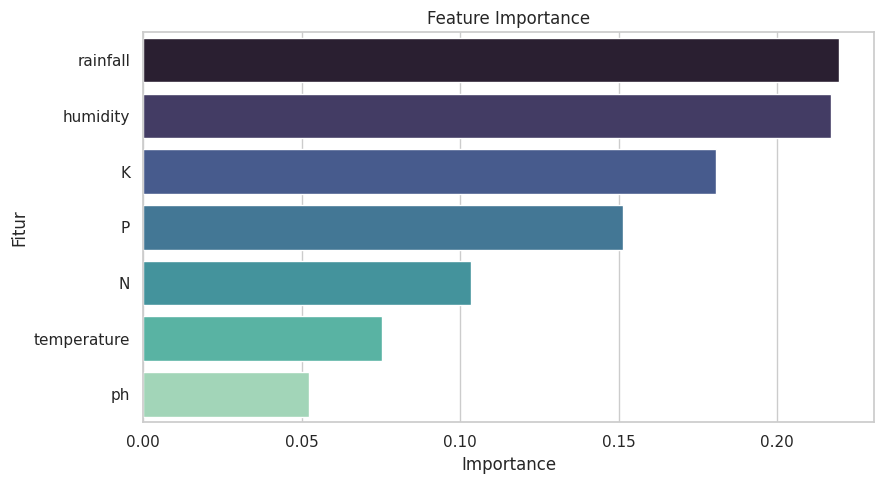

In [24]:
importance_df = pd.DataFrame({
    "feature": feature_columns,
    "importance": rf_model.feature_importances_,
}).sort_values("importance", ascending=False)

display(importance_df)

plt.figure(figsize=(9, 5))
sns.barplot(data=importance_df, x="importance", y="feature", palette="mako")
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Fitur")
plt.tight_layout()
plt.show()


### Interpretasi hasil cell 11

Feature importance menunjukkan fitur paling berpengaruh adalah `rainfall`, `humidity`, `K`, dan `P`. Artinya, pada dataset ini curah hujan, kelembapan, dan unsur hara tanah banyak membantu model membedakan jenis tanaman. Hasil ini dapat digunakan sebagai bahan pembahasan di laporan.


## 12. Contoh Fungsi Rekomendasi Tanaman

**Tujuan cell:** membuat fungsi sederhana untuk mencoba rekomendasi tanaman dari input manual.

**Penjelasan teknis:**

- Fungsi `recommend_crop()` menerima nilai `N`, `P`, `K`, suhu, kelembapan, pH, dan curah hujan.
- Input diubah menjadi DataFrame agar formatnya sama seperti data training.
- `predict_proba()` menghasilkan probabilitas untuk setiap jenis tanaman.
- `np.argsort()` digunakan untuk mengambil tanaman dengan probabilitas tertinggi.
- Output berupa tabel top-N rekomendasi tanaman.

**Alasan:** fungsi ini menjadi dasar prototype web Gradio karena logikanya sama: pengguna memasukkan kondisi lahan, lalu model mengembalikan rekomendasi tanaman.


In [25]:
def recommend_crop(N, P, K, temperature, humidity, ph, rainfall, top_n=3):
    input_data = pd.DataFrame([{
        "N": N,
        "P": P,
        "K": K,
        "temperature": temperature,
        "humidity": humidity,
        "ph": ph,
        "rainfall": rainfall,
    }])

    probabilities = rf_model.predict_proba(input_data)[0]
    top_index = np.argsort(probabilities)[::-1][:top_n]

    return pd.DataFrame({
        "crop": rf_model.classes_[top_index],
        "probability": probabilities[top_index],
    })

recommend_crop(90, 42, 43, 20.8, 82.0, 6.5, 202.9, top_n=5)


,crop,probability
0,rice,0.935
1,jute,0.065
2,pomegranate,0.000
3,pigeonpeas,0.000
4,papaya,0.000


### Interpretasi hasil cell 12

Output fungsi menampilkan beberapa tanaman dengan probabilitas tertinggi untuk contoh input yang diberikan. Fungsi ini menunjukkan bagaimana model bisa digunakan secara praktis: pengguna memasukkan nilai kondisi lahan, lalu sistem memberikan rekomendasi tanaman beserta tingkat keyakinan model.


## 13. Menyimpan Model

**Tujuan cell:** menyimpan model Random Forest yang sudah dilatih.

**Penjelasan teknis:**

- Model disimpan ke `/kaggle/working/random_forest_crop_recommendation.pkl`.
- File yang disimpan berisi model, daftar fitur, dan nama target.
- `joblib.dump()` digunakan karena umum dipakai untuk menyimpan model scikit-learn.

**Alasan:** model yang sudah disimpan dapat diunduh, digunakan ulang, atau dipakai di prototype web tanpa perlu training ulang.


In [26]:
model_path = "/kaggle/working/random_forest_crop_recommendation.pkl"

joblib.dump({
    "model": rf_model,
    "feature_columns": feature_columns,
    "target_column": target_column,
}, model_path)

print("Model tersimpan di:", model_path)


Model tersimpan di: /kaggle/working/random_forest_crop_recommendation.pkl


### Interpretasi hasil cell 13

Output menunjukkan model berhasil disimpan di folder `/kaggle/working/`. File `.pkl` ini dapat diunduh dari Kaggle dan dipakai kembali untuk demo atau prototype web tanpa menjalankan training ulang.


## 14. Ringkasan

Notebook ini menunjukkan bahwa Random Forest dapat digunakan untuk melakukan rekomendasi tanaman berdasarkan kondisi tanah dan lingkungan. Evaluasi dilakukan dengan train-test accuracy, classification report, confusion matrix, cross-validation, dan feature importance. Hasil utama notebook ini digunakan pada bagian Results dan Discussion laporan project.
